# Variabili d'ambiente


In [2]:
import os
import pandas as pd
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
load_dotenv()

NOTION_TOKEN = "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"

HEADERS = {
    "Authorization": f"Bearer {NOTION_TOKEN}",
    "Notion-Version": "2025-09-03",
    "Content-Type": "application/json"
}
Musc = "30cf7c61-2182-80a9-9eda-000bab2a315b"
Wei = "312f7c61-2182-8083-9c2c-000b2d8e7aac"
Exce = "313f7c61-2182-8076-870e-000b7fc806c5" 

## Creazione Funzioni per creare i dataframe a partire dai 3 dataset di notion

In [3]:


def extract_property(prop: dict, relation_map: dict = {}):
    ptype = prop["type"]
    extractors = {
        "title":        lambda p: p["title"][0]["plain_text"] if p["title"] else None,
        "rich_text":    lambda p: p["rich_text"][0]["plain_text"] if p["rich_text"] else None,
        "number":       lambda p: p["number"],
        "select":       lambda p: p["select"]["name"] if p["select"] else None,
        "multi_select": lambda p: [s["name"] for s in p["multi_select"]],
        "date":         lambda p: p["date"]["start"] if p["date"] else None,
        "checkbox":     lambda p: p["checkbox"],
        "url":          lambda p: p["url"],
        "formula":      lambda p: p["formula"].get("number") or p["formula"].get("string"),
        "relation":     lambda p: [relation_map.get(r["id"], r["id"]) for r in p["relation"]] if p["relation"] else None,
    }
    return extractors.get(ptype, lambda p: None)(prop)


def notion_datasource_to_df(data_source_id: str, relation_maps: dict = {}) -> pd.DataFrame:
    """
    data_source_id: ID del data source principale
    relation_maps: dizionario {nome_colonna: id_map} per risolvere le relation
    """
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"
    rows = []
    payload = {}

    while True:
        response = requests.post(url, headers=HEADERS, json=payload)
        data = response.json()

        for page in data["results"]:
            row = {"page_id": page["id"]}
            for col_name, prop in page["properties"].items():
                rel_map = relation_maps.get(col_name, {})
                row[col_name] = extract_property(prop, rel_map)
            rows.append(row)

        if data["has_more"]:
            payload["start_cursor"] = data["next_cursor"]
        else:
            break

    return pd.DataFrame(rows)

### Creazione dei 3 dataframe

In [4]:
muscles = notion_datasource_to_df(Musc)
excercices = notion_datasource_to_df(Exce)

weight = notion_datasource_to_df(Wei)
weight.drop(columns=['page_id','0'], inplace=True)

### Merge e pulizia iniziale dei dataframe Muscles e Exercises

In [5]:

excercices['Exercise'] = excercices['Exercise'].apply(lambda x: x[0] if isinstance(x, list) else x)
df = pd.merge(excercices, muscles, left_on='Exercise', right_on='page_id', how='left')

df.drop(columns=['page_id_y','page_id_x','Exercise_x'], inplace=True)
df

,Volume,Sets,Weight,Reps,Muscle,Date1,Date,Type,Muscle Group,Secondary Muscle,Primary Muscle,Equipment,Exercise_y
0,624,3,26,8,Bicipiti,2026-02-18,None,Pull,Bicipiti,—,Bicipiti,Bilanciere,Curl Bilanciere
1,768,3,32,8,Spalle,2026-02-17,None,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
2,468,3,26,6,Bicipiti,2026-02-18,None,Pull,Bicipiti,Bicipiti,Brachiale,Manubri,Hammer Curl
3,704,4,22,8,Spalle,2026-02-17,None,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
4,1020,3,34,10,Spalle,2026-02-23,None,Pull,Spalle,Trapezio,Deltoidi,Bilanciere,Tirate al Mento
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,300,5,20,3,Tricipiti,2026-03-22,Push,Push,Tricipiti,Tricipiti,Pettorali,Bodyweight,Dips
81,528,2,22,12,Spalle,2026-03-22,Push,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises
82,720,3,40,6,Spalle,2026-03-22,Push,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press
83,1248,4,52,6,Petto,2026-03-22,Push,Push,Petto,Deltoidi,Pettorali,Bilanciere,Panca Piana


### Pulizia e rinominazione delle colonne del nuovo dataframe chiamato per comodità df

In [6]:


#eliminazione collona Type e Volume
if 'Type' in df.columns:
    df.drop(columns=['Type', 'Volume'], inplace=True)
#rinominiazione colonna Date in Split e Date1 in Date
if 'Date1' in df.columns:
    df.rename(columns={'Date': 'Split', 'Date1': 'Date'}, inplace=True)
#eliminazione [] dalla colonna Exercise
if 'Exercise' in df.columns:
    df['Exercise'] = df['Exercise'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)



### Creazione della logica per il volume percepito da ogni gruppo muscolare
#### da modificare/eliminare i fattori di conversione per ogni muscolo, magari anche estendendo la logica ai muscoli secondari


In [ ]:

muscle_conversion = {
    "Spalle":    1.30,
    "Schiena":   0.80,
    "Tricipiti": 1.20,
    "Petto":     0.85,
    "Core":      1.10,
    "Gambe":     0.60,
    "Bicipiti":  1.40
}

def epley_1rm(weight, reps):
    return weight * (1 + reps / 30)

def intensity_multiplier(weight, reps):
    estimated_1rm = epley_1rm(weight, reps)
    pct_1rm = weight / estimated_1rm
    return 0.5 + pct_1rm  # scala l'intensità relativa

def weighted_volume(muscle, sets, reps, weight):
    coeff = muscle_conversion.get(muscle, 1.0)
    intensity = intensity_multiplier(weight, reps)
    return sets * reps * weight * coeff * intensity

# Creazione colonna volume in cui moltiplichiamo le ripetizioni per i set per il peso e per il coefficiente del muscolo e per l'intensità relativa

df['Volume'] = df.apply(lambda row: weighted_volume(row['Muscle'], row['Sets'], row['Reps'], row['Weight']), axis=1)
df



,Sets,Weight,Reps,Muscle,Date,Split,Muscle Group,Secondary Muscle,Primary Muscle,Equipment,Exercise_y,Volume,Day
0,3,26,8,Bicipiti,2026-02-18,None,Bicipiti,—,Bicipiti,Bilanciere,Curl Bilanciere,804.631579,18
1,3,32,8,Spalle,2026-02-17,None,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press,990.315789,17
2,3,26,6,Bicipiti,2026-02-18,None,Bicipiti,Bicipiti,Brachiale,Manubri,Hammer Curl,624.000000,18
3,4,22,8,Spalle,2026-02-17,None,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises,907.789474,17
4,3,34,10,Spalle,2026-02-23,None,Spalle,Trapezio,Deltoidi,Bilanciere,Tirate al Mento,1275.000000,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,5,20,3,Tricipiti,2026-03-22,Push,Tricipiti,Tricipiti,Pettorali,Bodyweight,Dips,422.727273,22
81,2,22,12,Spalle,2026-03-22,Push,Spalle,—,Deltoidi Laterali,Manubri,Lateral Raises,641.142857,22
82,3,40,6,Spalle,2026-03-22,Push,Spalle,Tricipiti,Deltoidi,Bilanciere,Military Press,960.000000,22
83,4,52,6,Petto,2026-03-22,Push,Petto,Deltoidi,Pettorali,Bilanciere,Panca Piana,1664.000000,22


### Grafico di prova per vedere il volume totale diviso per i vari gruppi muscolari

<Axes: xlabel='Muscle', ylabel='Volume'>

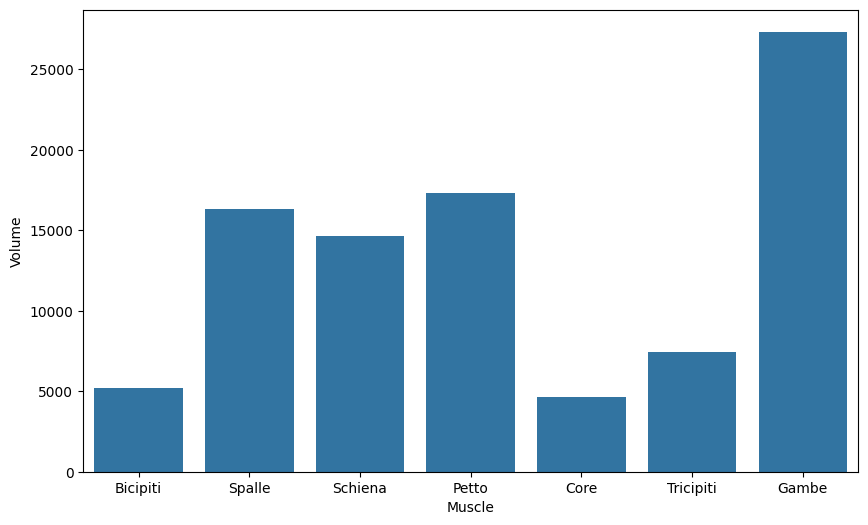

In [12]:
#histogramma del volume totale per ogni gruppo muscolare con come asse x i gruppi muscolare e come asse y il volume totale

plt.figure(figsize=(10, 6))
sns.barplot(x='Muscle', y='Volume', data=df, estimator=sum, errorbar=None)

### Heatmap calendario con tutti i giorni in cui c'è un allenamneto con il colore in base al volume giornaliero


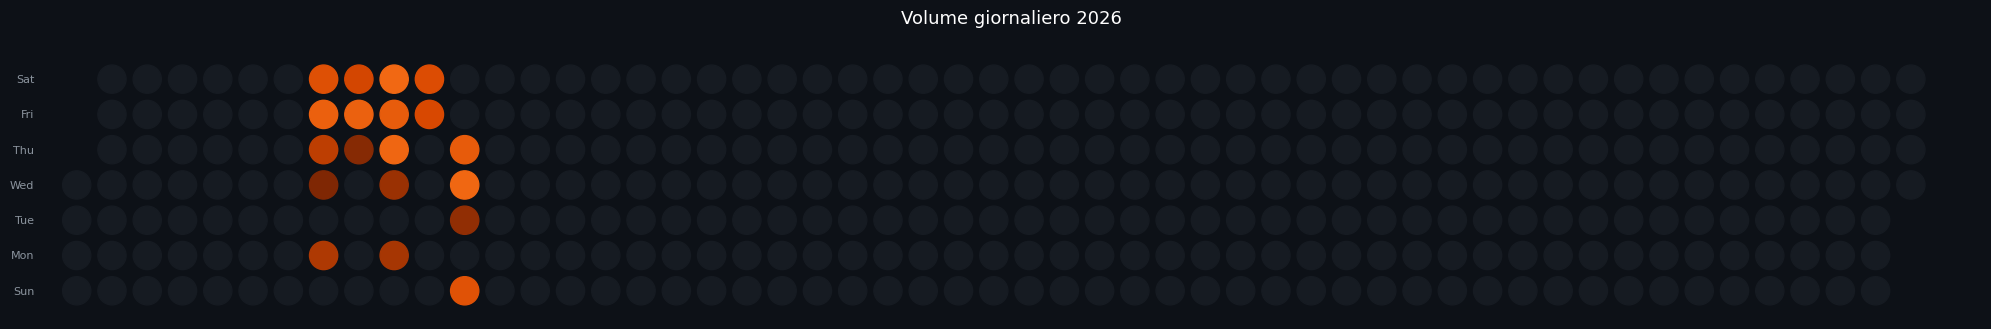

In [13]:
df['Date'] = pd.to_datetime(df['Date'])
train_2026 = df[df['Date'].dt.year == 2026].copy()

# Somma del volume per giorno invece del conteggio
daily_counts = train_2026.groupby('Date')['Volume'].sum().reset_index(name='volume')

# full 2026 calendar
calendar = pd.DataFrame({'Date': pd.date_range('2026-01-01', '2026-12-31', freq='D')})
calendar = calendar.merge(daily_counts, on='Date', how='left')
calendar['volume'] = calendar['volume'].fillna(0).astype(float)

start_weekday = pd.Timestamp('2026-01-01').weekday()
calendar['week'] = ((calendar['Date'] - pd.Timestamp('2026-01-01')).dt.days + start_weekday) // 7
calendar['weekday'] = calendar['Date'].dt.weekday

fig, ax = plt.subplots(figsize=(20, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

max_val = calendar['volume'].max()
cmap = plt.cm.Oranges

for _, row in calendar.iterrows():
    x = row['week']
    y = 6 - row['weekday']
    val = row['volume']

    if val == 0:
        color = '#161b22'
    else:
        color = cmap(0.3 + 0.7 * val / max_val if max_val > 0 else 0.3)

    circle = plt.Circle((x, y), 0.4, color=color)
    ax.add_patch(circle)

ax.set_xlim(-1, 54)
ax.set_ylim(-0.8, 7)
ax.set_aspect('equal')
ax.axis('off')

days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
for i, day in enumerate(days):
    ax.text(-1.2, i, day, color='#8b949e', va='center', ha='right', fontsize=8)

ax.set_title("Volume giornaliero 2026", color='white', pad=15, fontsize=13)
plt.tight_layout()
plt.show()
